In [1]:
from google.colab import files
uploaded = files.upload()

Saving Cleaned_Dataset for Data Analytics - Sheet1.csv to Cleaned_Dataset for Data Analytics - Sheet1.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Cleaned_Dataset for Data Analytics - Sheet1.csv')  # use your cleaned file from Project 1
print("Shape:", df.shape)
df.head()

Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']
print(df[numeric_cols].describe())

          Quantity    UnitPrice   TotalPrice  ItemsInCart
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750  1053.968300     5.485000
std       1.407557   197.177146   819.856558     2.281983
min       1.000000    11.390000    11.390000     1.000000
25%       2.000000   186.062500   410.520000     4.000000
50%       3.000000   364.210000   823.615000     5.000000
75%       4.000000   521.570000  1578.475000     7.000000
max       5.000000   699.930000  3456.400000    10.000000


In [4]:
for col in numeric_cols:
    mean = df[col].mean()
    median = df[col].median()
    print(f"{col}: mean={mean:.2f}, median={median:.2f}, diff={mean-median:.2f}")

Quantity: mean=2.95, median=3.00, diff=-0.05
UnitPrice: mean=356.41, median=364.21, diff=-7.80
TotalPrice: mean=1053.97, median=823.62, diff=230.35
ItemsInCart: mean=5.49, median=5.00, diff=0.49


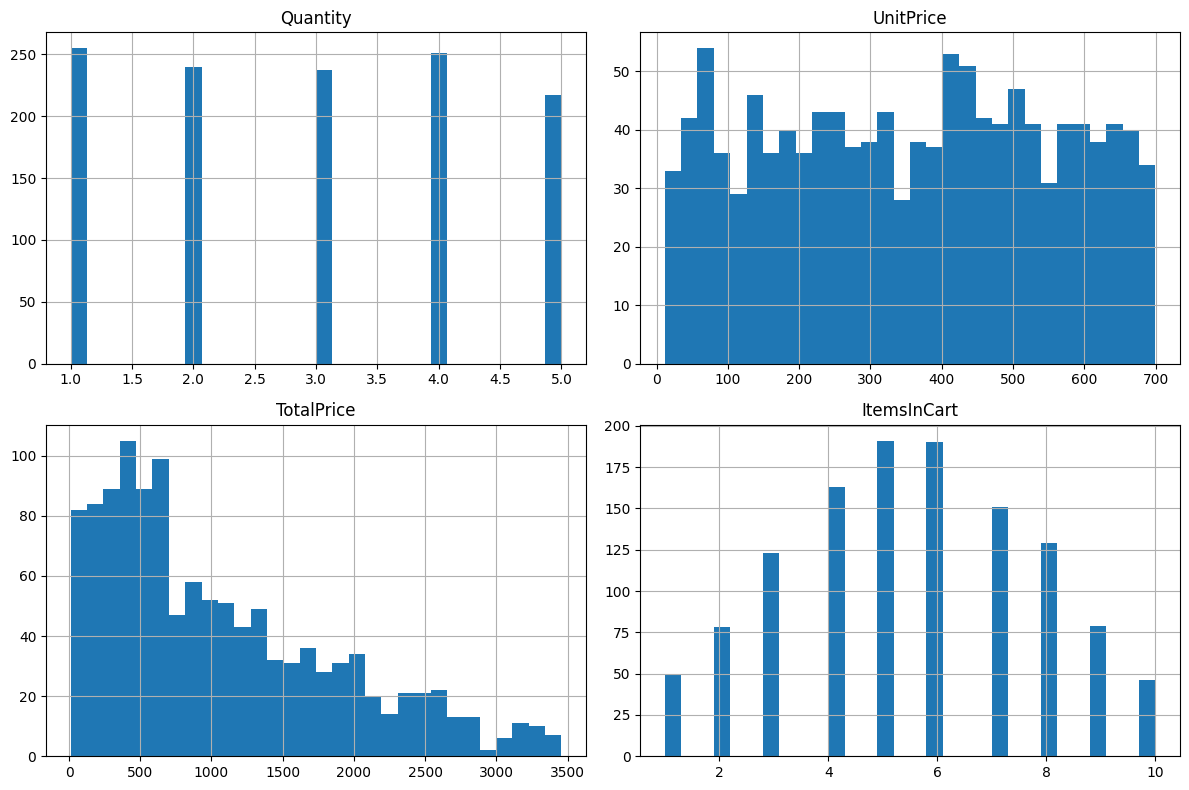

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    df[col].hist(bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

In [6]:
def find_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (range: {lower:.2f} to {upper:.2f})")
    return outliers

outlier_summary = {}
for col in numeric_cols:
    outlier_summary[col] = find_outliers_iqr(df, col)

Quantity: 0 outliers (range: -1.00 to 7.00)
UnitPrice: 0 outliers (range: -317.20 to 1024.83)
TotalPrice: 8 outliers (range: -1341.41 to 3330.41)
ItemsInCart: 0 outliers (range: -0.50 to 11.50)


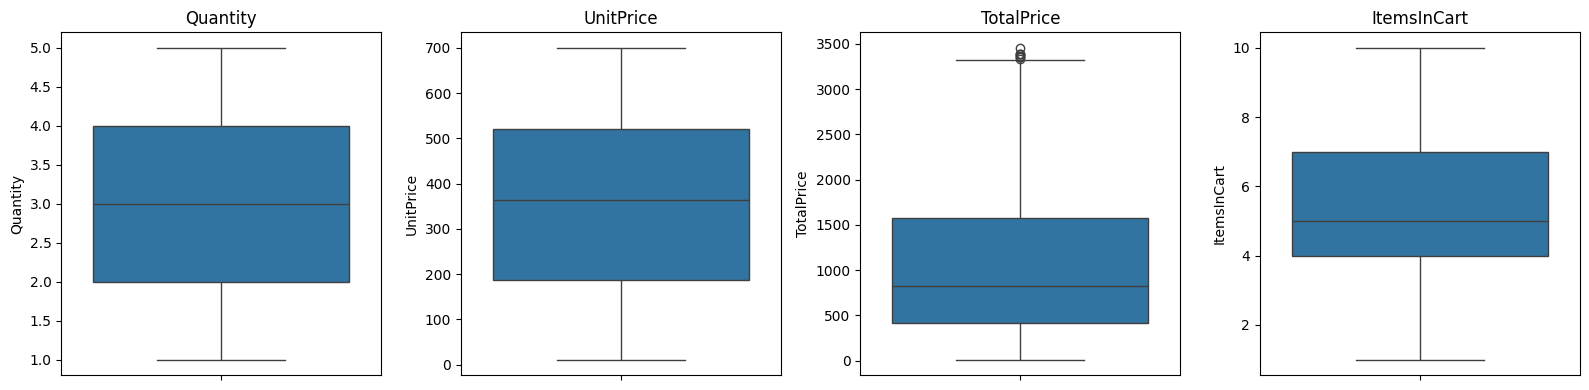

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

In [8]:
totalprice_outliers = outlier_summary['TotalPrice']
print(f"Found {len(totalprice_outliers)} high-value orders:")
print(totalprice_outliers[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']])

Found 8 high-value orders:
        OrderID  Product  Quantity  UnitPrice  TotalPrice
107   ORD200107  Printer         5     670.75     3353.75
326   ORD200326   Laptop         5     670.48     3352.40
328   ORD200328   Tablet         5     674.04     3370.20
469   ORD200469    Chair         5     676.98     3384.90
632   ORD200632   Laptop         5     678.16     3390.80
789   ORD200789   Tablet         5     691.28     3456.40
1065  ORD201065  Printer         5     666.80     3334.00
1122  ORD201122  Monitor         5     678.19     3390.95


             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity     1.000000   0.014553    0.615251     0.650061
UnitPrice    0.014553   1.000000    0.717081     0.000602
TotalPrice   0.615251   0.717081    1.000000     0.392540
ItemsInCart  0.650061   0.000602    0.392540     1.000000


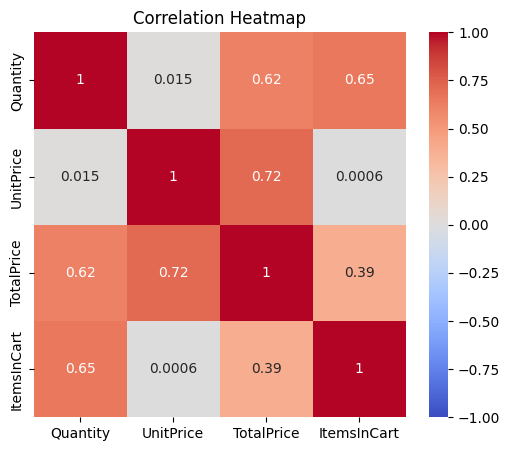

In [9]:
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

In [10]:
categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Product ---
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

--- OrderStatus ---
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

--- ReferralSource ---
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


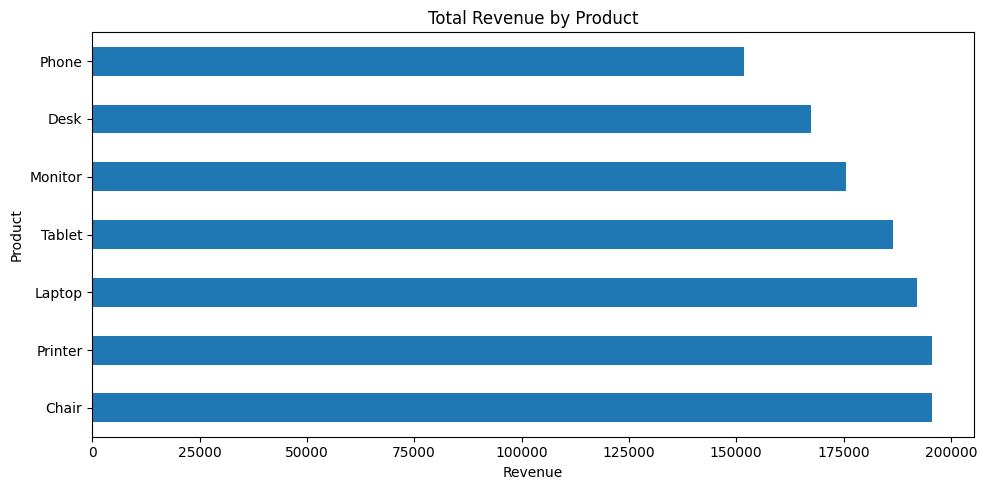

In [11]:
revenue_by_product = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print(revenue_by_product)

plt.figure(figsize=(10, 5))
revenue_by_product.plot(kind='barh')
plt.title('Total Revenue by Product')
plt.xlabel('Revenue')
plt.tight_layout()
plt.savefig('revenue_by_product.png')
plt.show()

In [12]:
print("=== KEY FINDINGS ===")
print(f"1. Average order value: ${df['TotalPrice'].mean():.2f} (median: ${df['TotalPrice'].median():.2f})")
print(f"2. {len(outlier_summary['TotalPrice'])} high-value outlier orders detected in TotalPrice")
print(f"3. Strongest correlation: UnitPrice & TotalPrice (r = {corr_matrix.loc['UnitPrice','TotalPrice']:.2f})")
print(f"4. Top-selling product by revenue: {revenue_by_product.index[0]}")
print(f"5. Most common payment method: {df['PaymentMethod'].value_counts().index[0]}")

=== KEY FINDINGS ===
1. Average order value: $1053.97 (median: $823.62)
2. 8 high-value outlier orders detected in TotalPrice
3. Strongest correlation: UnitPrice & TotalPrice (r = 0.72)
4. Top-selling product by revenue: Chair
5. Most common payment method: Online


In [13]:
summary_df = pd.DataFrame({
    'Metric': ['Mean TotalPrice', 'Median TotalPrice', 'Outliers in TotalPrice',
               'Top Product', 'Most Common Payment'],
    'Value': [df['TotalPrice'].mean(), df['TotalPrice'].median(),
              len(outlier_summary['TotalPrice']), revenue_by_product.index[0],
              df['PaymentMethod'].value_counts().index[0]]
})
summary_df.to_csv('eda_summary.csv', index=False)
print(summary_df)

                   Metric      Value
0         Mean TotalPrice  1053.9683
1       Median TotalPrice    823.615
2  Outliers in TotalPrice          8
3             Top Product      Chair
4     Most Common Payment     Online
